# Path-Analysis Charts

## Imports

In [185]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

from reeb_utils import collapse_traj

pd.options.mode.chained_assignment = None

## Load data

In [186]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

## Test phase

In [187]:
# only consider test trials 
test_df = df[df["eprocs"].str.contains("Test")]
test_df["StartEnd"] = test_df["StartAt"] + test_df["EndAt"]

# Compute quartiles for participants
test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["quartile"] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

# Compute accuracy for each path
test_df["path_mean_acc"] = test_df.groupby("StartEnd")["accuracy"].transform("mean")

# Calculate trajectory (no turns, just nodes)
test_df["trajs"] = test_df["paths"].apply(lambda x: "".join(collapse_traj(x.split())))

### Path accuracy by quartile
Plot all the trials, order them by % correct, with a histogram (light gray scale). Add to this graph lines or points, colored by quartile (e.g. the top quartile might get 100% on the easy ones, while the bottom might get 60%). In this graph you are looking at how the different quartiles compare, going from easy to difficult. 

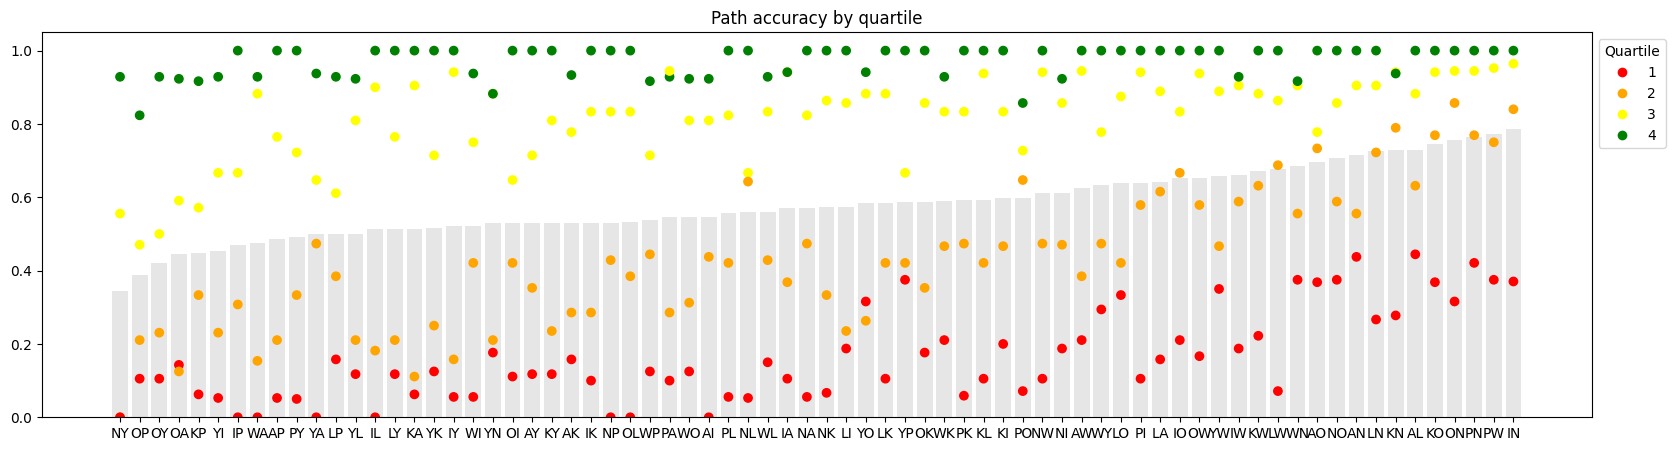

In [188]:
fig, ax = plt.subplots(figsize=(20, 5))

# Plot trial histogram, ordered by % correct, grayscale
path_accs = test_df[["StartEnd", "path_mean_acc"]].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

ax.bar(path_accs["StartEnd"], path_accs["path_mean_acc"], color="0.9")

# Plot accuracies by quartile.
test_df["path_quartile_mean_acc"] = test_df.groupby(["StartEnd", "quartile"], observed=True)["accuracy"].transform("mean")
q_path_accs = test_df[["StartEnd", "quartile", "path_quartile_mean_acc"]].drop_duplicates(subset=["StartEnd", "quartile"], keep="first")

color_dict = {1: "red", 2: "orange", 3: "yellow", 4: "green"}
q_path_accs["color"] = q_path_accs["quartile"].apply(lambda x: color_dict[x])

ax.scatter(q_path_accs["StartEnd"], q_path_accs["path_quartile_mean_acc"], color=q_path_accs["color"])

# Add axis labels, legend, and show plot
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='Quartile', handles=handles, bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Path accuracy by quartile")
plt.show()

### Metrics and path accuracies
For the same grayscale background ordering the graphs by overall difficulty, also plot graph metrics of the minimal path (e.g. length, number of turns, etc which are required to complete the minimal path). In this result you are comparing the path with its metrics. 

In [189]:
# need to set this to do the masking below; else error
test_df["accuracy"] = test_df["accuracy"].astype('bool')

# Calculate min turns; first set turns very high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["fake_turns"] = test_df["turns_count"]
test_df.loc[~test_df["accuracy"], "fake_turns"] = 999

test_df["min_turns"] = test_df.groupby("StartEnd")["fake_turns"].transform("min")

# Calculate min path dist; first set v high for the wrong people
# Note: there's definitely a smarter way to do this in pandas
test_df["fake_dist"] = test_df["trajs"].apply(len)
test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

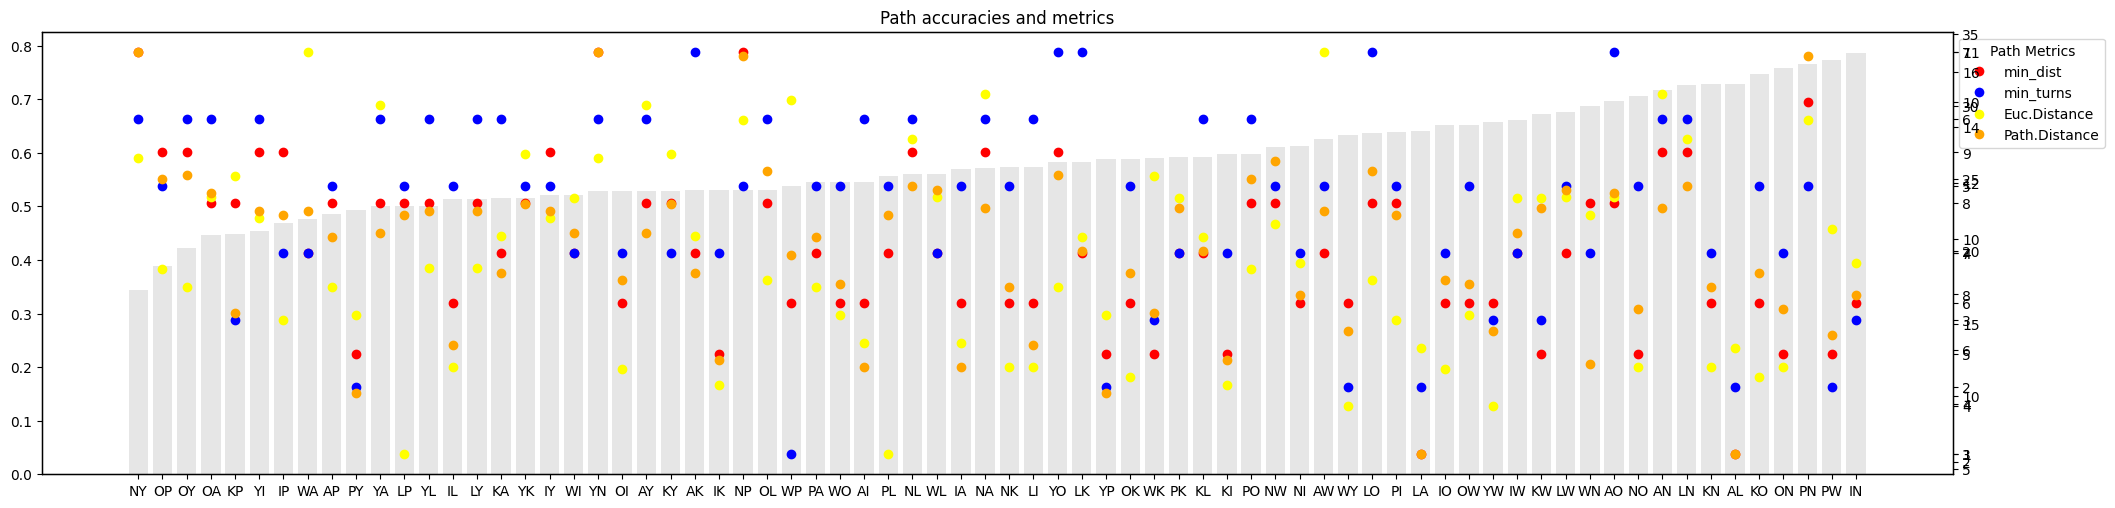

In [251]:
fig, ax = plt.subplots(figsize=(20, 5))

metrics_to_plot = ["min_dist", "min_turns", "Euc.Distance", "Path.Distance"]
colors = ["red", "blue", "yellow", "orange"]

# Plot trial histogram, ordered by % correct, grayscale
path_accs = test_df[["StartEnd", "path_mean_acc"] + metrics_to_plot].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

ax.bar(path_accs["StartEnd"], path_accs["path_mean_acc"], color="0.9")

# Plot metrics
for metric, color in zip(metrics_to_plot, colors):
    # instantiate another axes that shares the same x-axis
    ax2 = ax.twinx()  
    # ax2.set_ylabel(metric, color=color)  # TODO: figure out how to label axes
    ax2.scatter(path_accs["StartEnd"], path_accs[metric], color=color)


# Plot start/end explore visits
# ax2 = ax.twinx()  
# ax2.scatter(path_accs["StartEnd"], [node_visit_dict[x[0]] for x in path_accs["StartEnd"]], color="green")

# ax2 = ax.twinx()  
# ax2.scatter(path_accs["StartEnd"], [node_visit_dict[x[1]] for x in path_accs["StartEnd"]], color="purple")

# Add axis labels, legend, and show plot
fig.tight_layout() 
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, label=metric, markersize=8) for metric, color in zip(metrics_to_plot, colors)]
ax.legend(title='Path Metrics', handles=handles, bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Path accuracies and metrics")
plt.show()

# is it starting position or target or both that drives accuracy
# are there certain decision points that are confusable

### Min is most popular?
Check whether the minimal path is the most popular path (regardless of whether people got it right or wrong) across all the test paths. Also check if this is true for all quartiles. For the top quartile maybe everyone takes it, while for the bottom quartile, fewer will take it, but it still might be most popular. 

In [191]:
# get most popular path
def most_popular(paths):
    counts = {}
    for p in paths:
        counts[p] = counts.get(p, 0) + 1
    return max(counts, key=lambda x: counts[x])

def how_many_took(paths):
    counts = {}
    for p in paths:
        counts[p] = counts.get(p, 0) + 1
    return max(counts.values()) / len(paths)
    
test_df["most_popular_path"] = test_df.groupby(["StartEnd"])["trajs"].transform(most_popular)
test_df["pct_took_most_popular_path"] = test_df.groupby(["StartEnd"])["trajs"].transform(how_many_took)

test_df["most_popular_path-BY_Q"] = test_df.groupby(["StartEnd", "quartile"], observed=True)["trajs"].transform(most_popular)
test_df["pct_took_most_popular_path-BY_Q"] = test_df.groupby(["StartEnd", "quartile"], observed=True)["trajs"].transform(how_many_took)

# is most popular path the best?
test_df["pop_is_min"] = (test_df["most_popular_path"].apply(len) == test_df["min_dist"])
test_df["pop_is_min-BY_Q"] = (test_df["most_popular_path-BY_Q"].apply(len) == test_df["min_dist"])

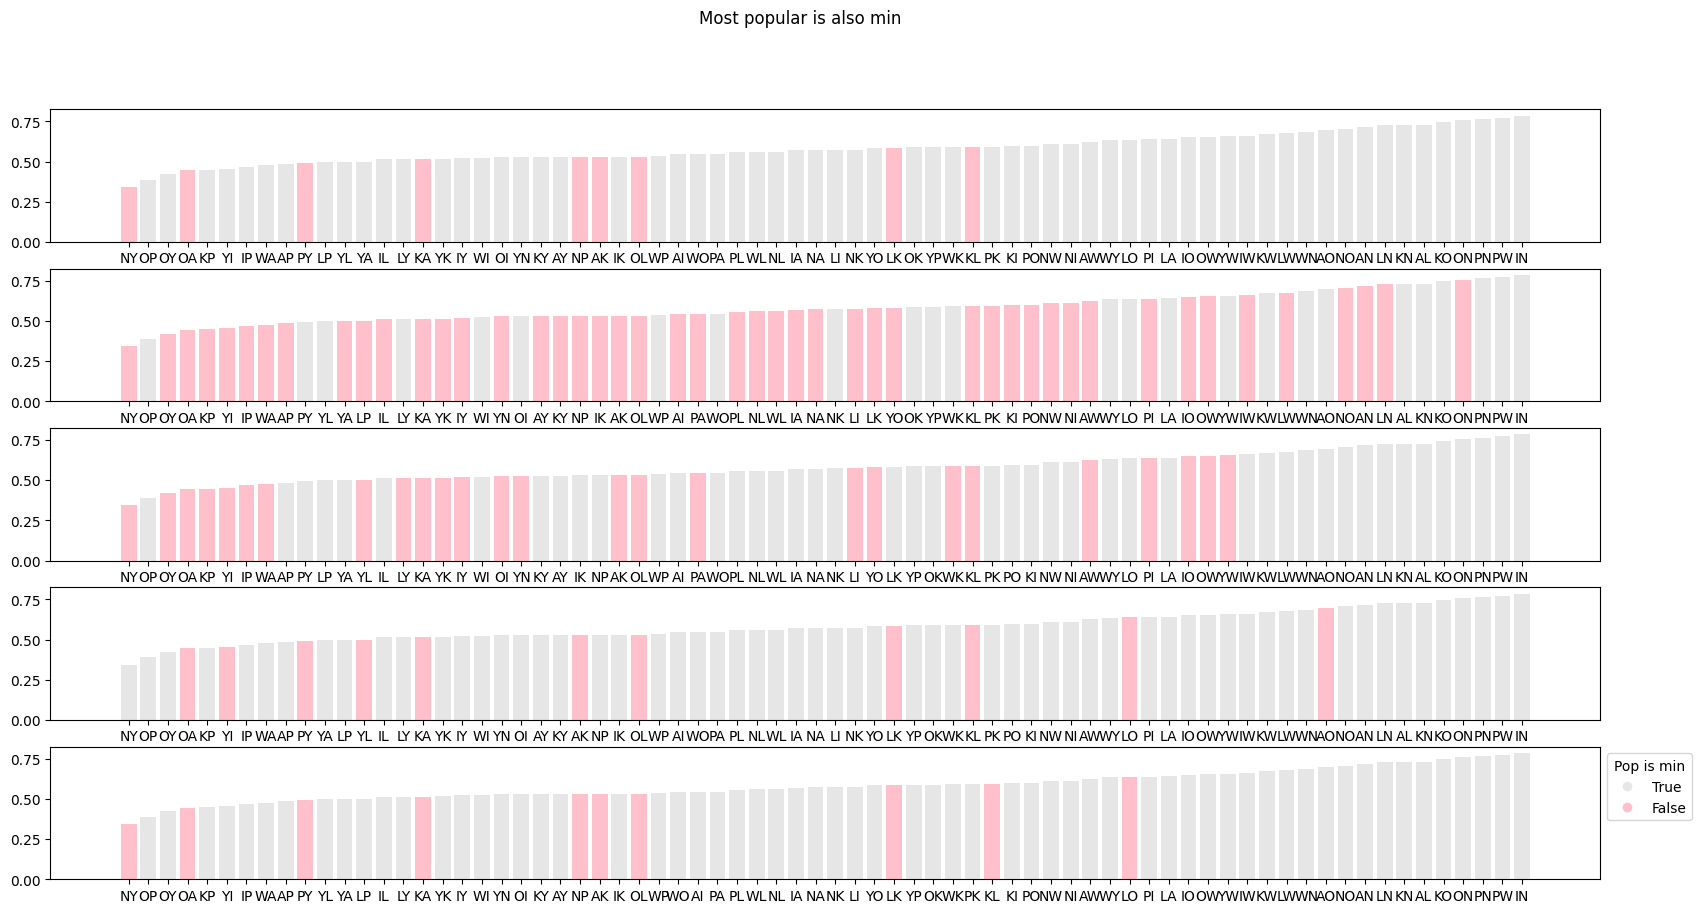

In [192]:
## PLOT popular is min
fig, axs = plt.subplots(5, 1, figsize=(20, 10))

sorted_df = test_df
sorted_df = sorted_df.sort_values("path_mean_acc")

# Plot trial histogram, ordered by % correct, grayscale
path_accs = sorted_df[["StartEnd", "path_mean_acc", "pop_is_min"]].drop_duplicates(subset=["StartEnd"], keep="first")

color_dict = {True: "0.9", False: "pink"}
axs[0].bar(path_accs["StartEnd"], path_accs["path_mean_acc"], color=path_accs["pop_is_min"].apply(lambda x: color_dict[x]))

for q in range(1, 5):
    ax = axs[q]

    this_df = sorted_df[sorted_df["quartile"] == q]

    # Plot trial histogram, ordered by % correct, grayscale
    path_accs = this_df[["StartEnd", "path_mean_acc", "pop_is_min-BY_Q"]].drop_duplicates(subset=["StartEnd"], keep="first")
    # path_accs = path_accs.sort_values("path_mean_acc")

    color_dict = {True: "0.9", False: "pink"}
    ax.bar(path_accs["StartEnd"], path_accs["path_mean_acc"], color=path_accs["pop_is_min-BY_Q"].apply(lambda x: color_dict[x]))

# Add axis labels, legend, and show plot
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='Pop is min', handles=handles, bbox_to_anchor=(1, 1), loc='upper left')
plt.suptitle("Most popular is also min")
plt.show()

# look at what other path is when it's not the minimum
# how many people are taking most popular 

You could also superimpose which fraction take the minimal by quartile and overall on the path difficulty grayscale histogram. 

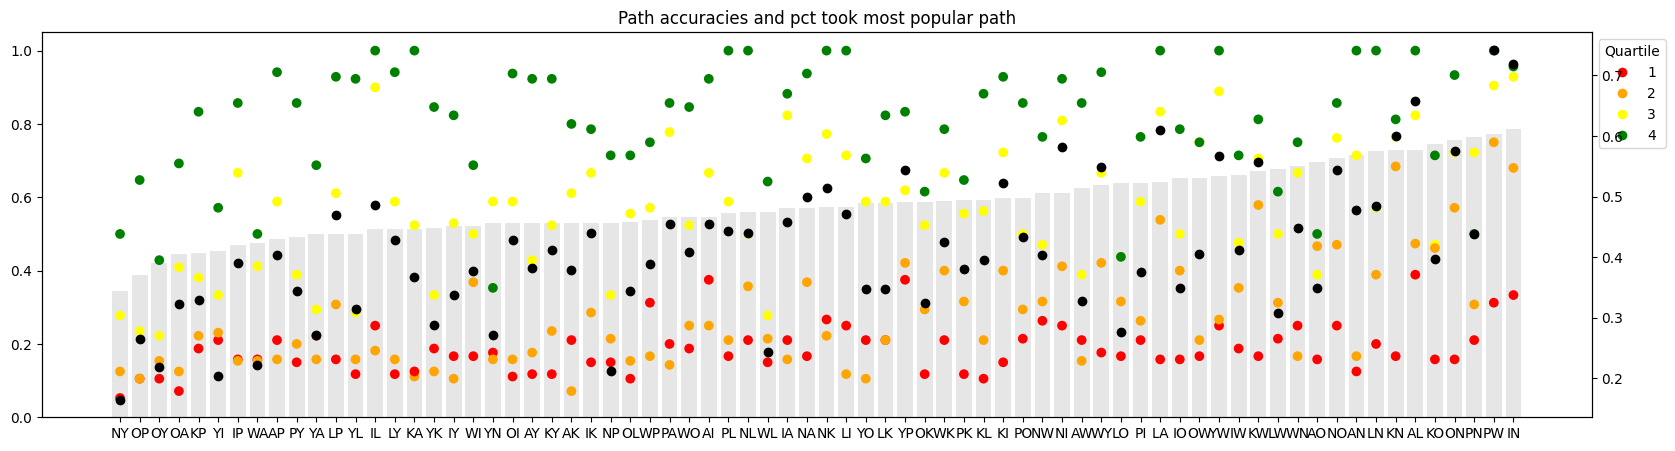

In [193]:
fig, ax = plt.subplots(figsize=(20, 5))

metrics_to_plot = ["pct_took_most_popular_path"]
colors = ["black"]

# Plot trial histogram, ordered by % correct, grayscale
path_accs = test_df[["StartEnd", "path_mean_acc"] + metrics_to_plot].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

ax.bar(path_accs["StartEnd"], path_accs["path_mean_acc"], color="0.9")

# Plot metrics
for metric, color in zip(metrics_to_plot, colors):
    # instantiate another axes that shares the same x-axis
    ax2 = ax.twinx()  
    # ax2.set_ylabel(metric, color=color)  # TODO: figure out how to label axes
    ax2.scatter(path_accs["StartEnd"], path_accs[metric], color=color)

# Plot accuracies by quartile.
test_df["path_quartile_mean_acc"] = test_df.groupby(["StartEnd", "quartile"], observed=True)["accuracy"].transform("mean")
q_path_accs = test_df[["StartEnd", "quartile", "pct_took_most_popular_path-BY_Q"]].drop_duplicates(subset=["StartEnd", "quartile"], keep="first")

color_dict = {1: "red", 2: "orange", 3: "yellow", 4: "green"}
q_path_accs["color"] = q_path_accs["quartile"].apply(lambda x: color_dict[x])

ax.scatter(q_path_accs["StartEnd"], q_path_accs["pct_took_most_popular_path-BY_Q"], color=q_path_accs["color"])

# Add axis labels, legend, and show plot
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='Quartile', handles=handles, bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Path accuracies and pct took most popular path")
plt.show()

## Learning phase

How often do they go through each node, first and second phase. 

In [223]:
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
for index, row in test_df[["Subject", "quartile"]].iterrows():
    subj, q = row["Subject"], row["quartile"]
    if subj not in q_dict:
        q_dict[subj] = q

explore_df["quartile"] = explore_df["Subject"].map(q_dict)

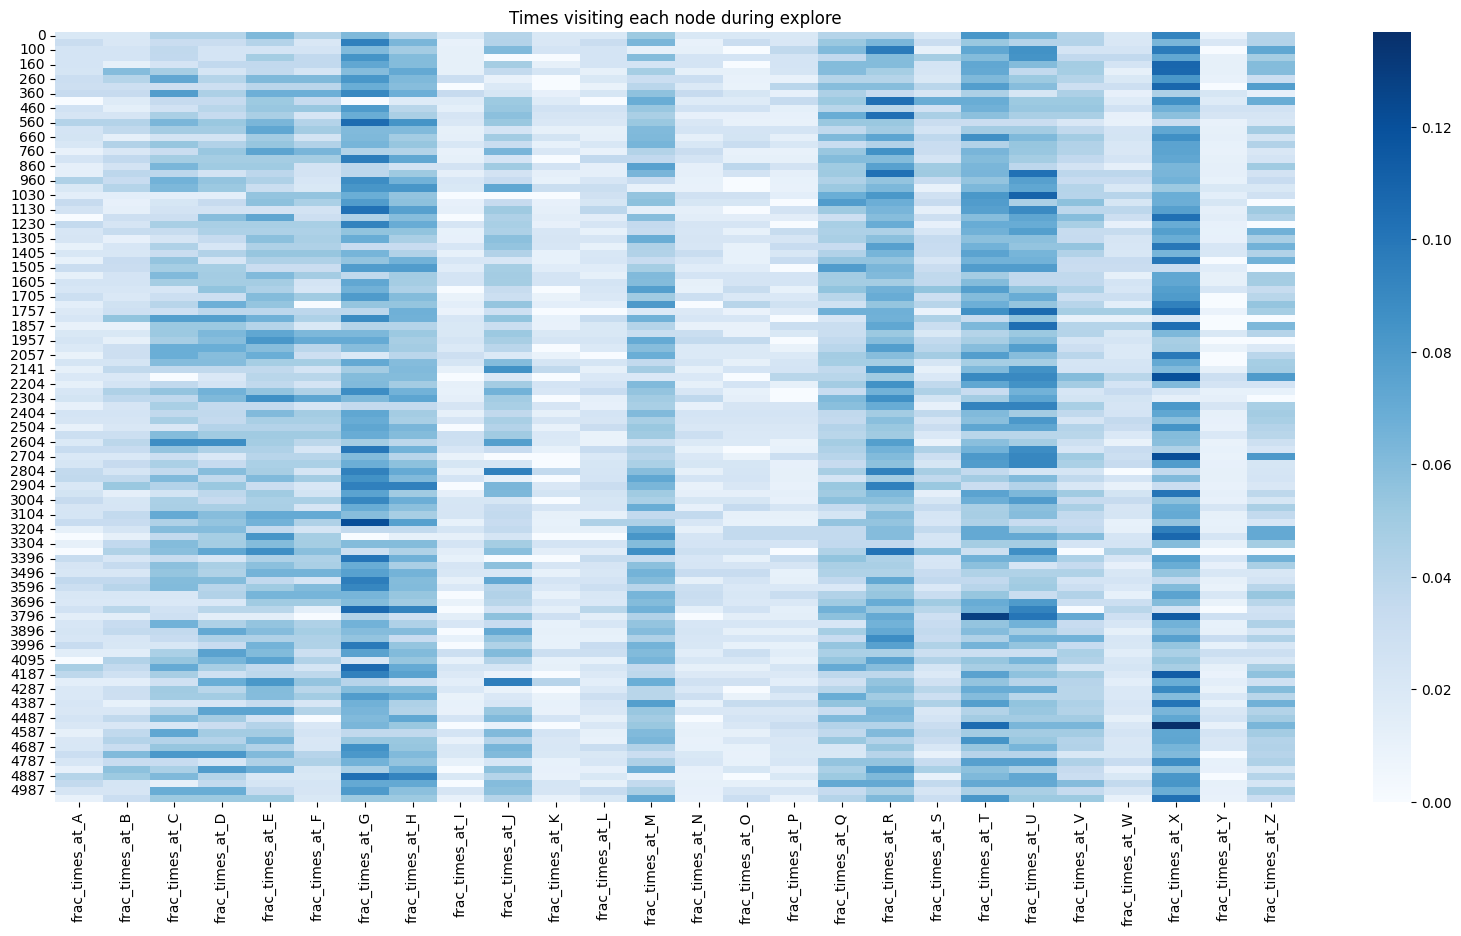

In [231]:
def compute_explore_traj(e_path):
    # need to replace V-east (V2) with Y and F-south (F3) with N
    # because they are facing and can see the object from there
    path = e_path.replace("V2", "Y2")
    path = e_path.replace("F3", "N3")
    
    nodes = path.split()
    nodes.remove("NA")
    nodes = [n[0] for n in nodes]

    return "".join(collapse_traj(nodes))

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
for node in alphabet:
    explore_df["times_at_" + node] = explore_df["explore_traj"].str.count(node)
    explore_df["frac_times_at_" + node] = explore_df["explore_traj"].str.count(node) / explore_df["num_nodes_visited"]

# PLOT BY SUBJECT
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

df_heatmap = explore_df[["frac_times_at_" + node for node in alphabet]]
sns.heatmap(df_heatmap, cmap="Blues", ax=ax)
ax.set_title("Times visiting each node during explore")

plt.show()

How often do they visit each node by quartile, first and second phases.

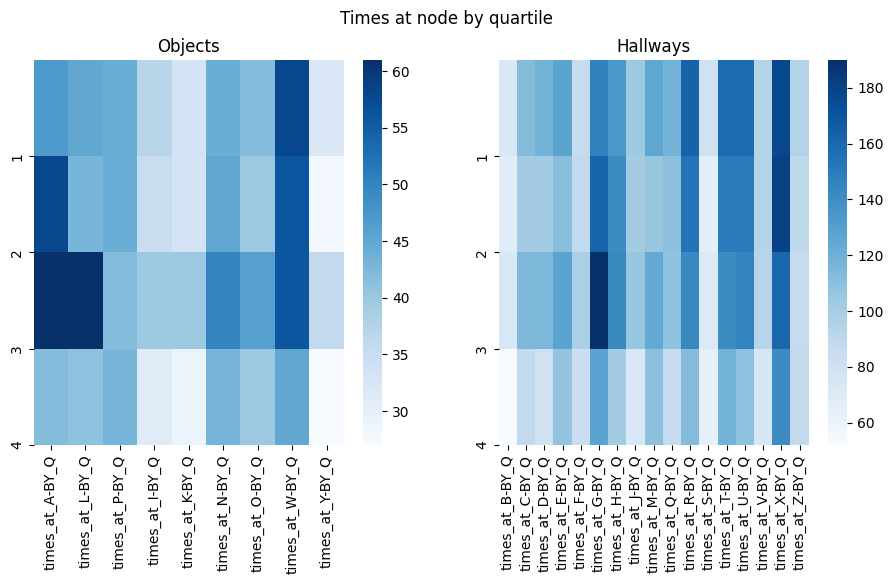

In [242]:
for node in alphabet:
    explore_df[f"times_at_{node}-BY_Q"] = explore_df.groupby(["quartile"], observed=True)[f"times_at_{node}"].transform("sum")


to_plot = explore_df[["quartile"] + [f"times_at_{node}-BY_Q" for node in alphabet]].drop_duplicates(subset=["quartile"], keep="first")
to_plot = to_plot[~to_plot["quartile"].isna()]

fig, axs = plt.subplots(1, 2, figsize=(11, 5))

objects = "ALPIKNOWY" 
hallways = "BCDEFGHJMQRSTUVXZ"

df_heatmap = to_plot.sort_values("quartile")[[f"times_at_{node}-BY_Q" for node in objects]]
sns.heatmap(df_heatmap, cmap="Blues", ax=axs[0])
axs[0].set_title("Objects")
axs[0].set_yticks([1,2,3,4], [1,2,3,4])

df_heatmap = to_plot.sort_values("quartile")[[f"times_at_{node}-BY_Q" for node in hallways]]
sns.heatmap(df_heatmap, cmap="Blues", ax=axs[1])
axs[1].set_title("Hallways")
axs[1].set_yticks([1,2,3,4], [1,2,3,4])

fig.suptitle("Times at node by quartile")
plt.show()

# test_df["pct_took_most_popular_path-BY_Q"] = test_df.groupby(["StartEnd", "quartile"], observed=True)["trajs"].transform(how_many_took)
# y are people not visiting y
# why is it hard to go to n / y and why does that hurt test phase.
# are they related
# why do best people go more slowly and visit less?
# dist travelled is not correlated w correct; evenness/ entropy of exploration is correlated ! (top range isn't as big)
# environment makes some tings easier; people strategies also affect this
# total object visits is correlated w pct correct; total hallway visits is not correlated
# guided person even w great exploration path not correlated; they gotta learn it for themselves?
# you can see object at F and V
# count V facing east & F facing south as visiting Y and N

# information gain too, bridges, etc
# gender differences in paths/exploration

In [246]:
# AGGREGATE ALL 
times_visited_per_node = []
node_visit_dict = {}
node_colors = []
for node in alphabet:
    times_visited_per_node.append(sum(list(explore_df[f"times_at_{node}"])))
    node_visit_dict[node] = times_visited_per_node[-1]
    node_colors.append("pink" if node in objects else "0.9")

n_visited = sum(list(explore_df["num_nodes_visited"]))
explore_df["num_nodes_visited-GLOBAL"] = n_visited

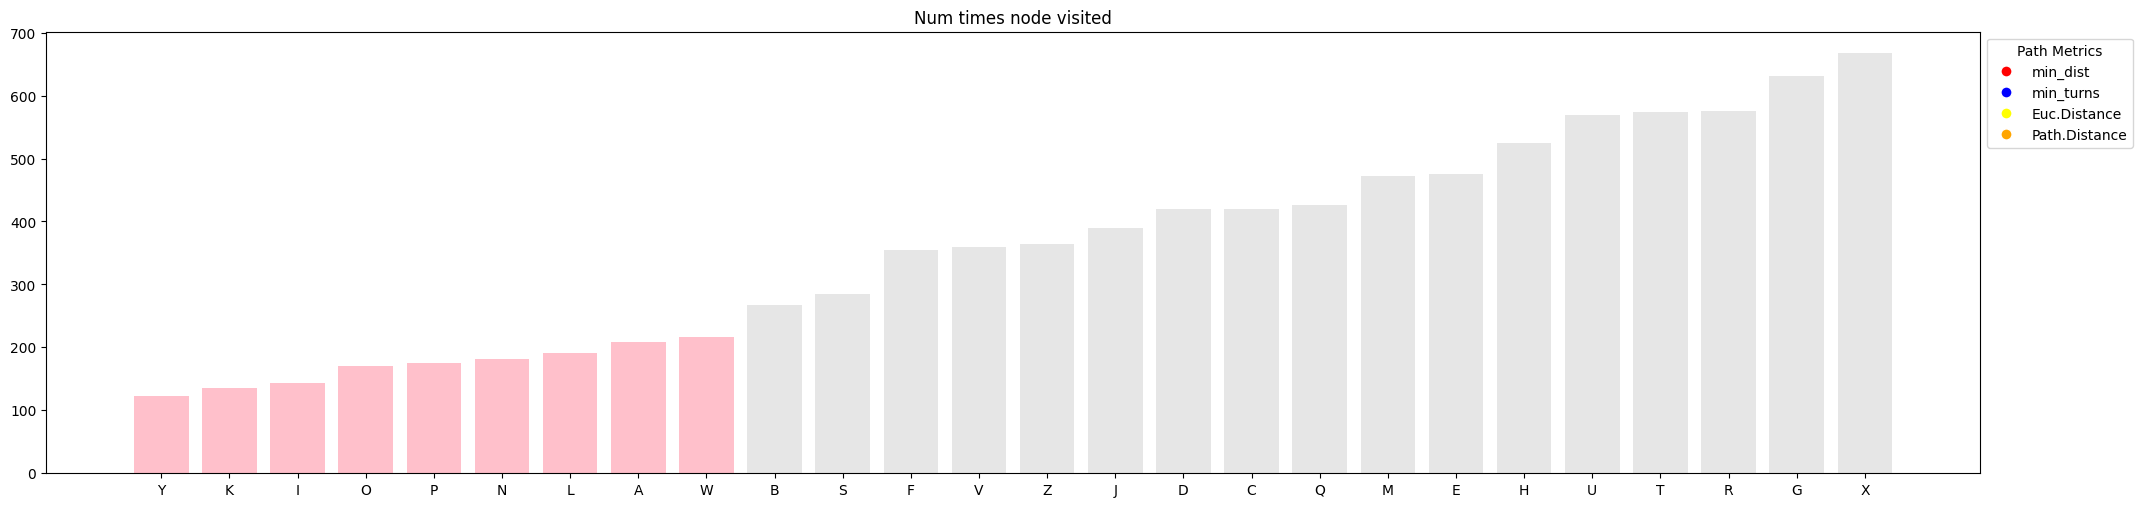

In [252]:
fig, ax = plt.subplots(figsize=(20, 5))

# Plot trial histogram, ordered by % correct, grayscale
df_visited = pd.DataFrame({"node": [a for a in alphabet], "n_visit": times_visited_per_node, "colors": node_colors})
df_visited = df_visited.sort_values("n_visit")
ax.bar(df_visited["node"], df_visited["n_visit"], color=df_visited["colors"])

# TODO: metrics to plot: degree?

# metrics_to_plot = ["min_dist", "min_turns"]
# colors = ["red", "blue"]

# # Plot metrics
# for metric, color in zip(metrics_to_plot, colors):
#     # instantiate another axes that shares the same x-axis
#     ax2 = ax.twinx()  
#     # ax2.set_ylabel(metric, color=color)  # TODO: figure out how to label axes
#     ax2.scatter(path_accs["StartEnd"], path_accs[metric], color=color)

# Add axis labels, legend, and show plot
fig.tight_layout() 
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, label=metric, markersize=8) for metric, color in zip(metrics_to_plot, colors)]
ax.legend(title='Path Metrics', handles=handles, bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Num times node visited")
plt.show()

## TODO

Divide treeb analysis so the number is equal, even if it does not separate to first and second phases. 

Correlations between node visits in learning and graph metrics for that node

Do the node visits and treeb metrics in learning correlate with whether the node is part of the minimal and path difficulty in the test phase?

You could look at how performance in the trail phase correlated with how the nodes are explore in the learning phase— which might be an interesting differentiator especially for hard paths